### ¿Qué es la visión artificial?

La visión artificial (o visión por computadora) es un campo de la inteligencia artificial (IA) que dota a las computadoras y máquinas con la capacidad de procesar, analizar y comprender el mundo visual a través de imágenes y videos.

### Detección de rostros con Python usando OpenCV

In [1]:
# 1. Instalación de librerías necesarias (si no están instaladas)
# !pip install "opencv-python<5" matplotlib

import os
import cv2

# 2. Cargar imagen
imgpath = 'images.jpg'
if not os.path.exists(imgpath):
    imgpath = os.path.join(os.getcwd(), 'Modelos_ML', 'Visionartificial', 'images.jpg')

# 3. Leer la imagen
img = cv2.imread(imgpath)
if img is None:
    raise FileNotFoundError(f"No se pudo cargar la imagen en: {imgpath}")

# 4. Mostrar dimensiones de la imagen (alto, ancho, canales de color)
print(f"Dimensiones de la imagen: {img.shape}")
img.shape


Dimensiones de la imagen: (678, 452, 3)


(678, 452, 3)

In [2]:
# 5. Convertir la imagen a escala de grises para el clasificador
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
print(f"Dimensiones en escala de grises: {gray_img.shape}")
gray_img.shape


Dimensiones en escala de grises: (678, 452)


(678, 452)

### Carga del clasificador Haar Cascade y detección de rostros

In [3]:
import os
import cv2

# Cargar clasificador de rostros Haar Cascade
cascade_path = "haarcascade_frontalface_default.xml"
if not os.path.exists(cascade_path):
    alt_path = os.path.join(os.getcwd(), 'Modelos_ML', 'Visionartificial', 'haarcascade_frontalface_default.xml')
    cascade_path = alt_path if os.path.exists(alt_path) else os.path.join(cv2.data.haarcascades, "haarcascade_frontalface_default.xml")

face_cascade = cv2.CascadeClassifier(cascade_path)

# Respaldo si no cargó el archivo local
if face_cascade.empty():
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

# Verificar si el clasificador cargó correctamente
if face_cascade.empty():
    print("Error: No se pudo cargar el clasificador, verificar el archivo xml")
else:
    print("Clasificador cargado correctamente")


Clasificador cargado correctamente


In [4]:
# Detectar rostros usando detectMultiScale
faces = face_cascade.detectMultiScale(
    gray_img,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(40, 40)
)

# Variable de compatibilidad
face = faces
print(f"Rostros detectados: {len(faces)}")


Rostros detectados: 1


In [5]:
# Dibujar los rectángulos de los rostros detectados sobre una copia de la imagen
img_detected = img.copy()

for (x, y, w, h) in faces:
    cv2.rectangle(img_detected, (x, y), (x + w, y + h), (0, 255, 0), 2)

# Convertir de formato BGR (OpenCV) a RGB (Matplotlib)
img_rgb = cv2.cvtColor(img_detected, cv2.COLOR_BGR2RGB)


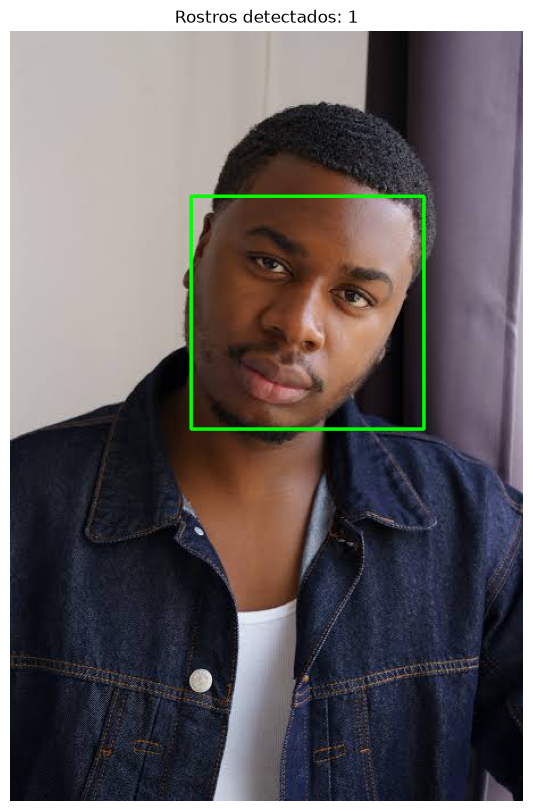

In [6]:
import matplotlib.pyplot as plt

# Mostrar el resultado con Matplotlib
plt.figure(figsize=(10, 10))
plt.imshow(img_rgb)
plt.axis('off')
plt.title(f"Rostros detectados: {len(faces)}")
plt.show()


In [7]:
# Función para detectar rostros en cada fotograma del video y dibujar los recuadros
def detect_bounding_box(vid):
    gray_img = cv2.cvtColor(vid, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray_img, scaleFactor=1.1, minNeighbors=5, minSize=(40, 40))
    for (x, y, w, h) in faces:
        cv2.rectangle(vid, (x, y), (x + w, y + h), (0, 255, 0), 2)
    return faces


In [8]:
# Bucle para detectar rostros en tiempo real desde la cámara web
video_capture = cv2.VideoCapture(0)

if not video_capture.isOpened():
    print("Aviso: No se pudo abrir la cámara web (puede que no haya una disponible o esté en uso por otra app).")
else:
    print("Cámara iniciada. Enfoca la cámara y presiona la tecla 'q' en la ventana para salir.")
    try:
        while True:
            result, video_frame = video_capture.read()
            if not result:
                print("No se pudo leer el fotograma del video.")
                break

            # Aplicar detección de rostros
            faces = detect_bounding_box(video_frame)

            # Mostrar ventana con el video
            cv2.imshow("Detección de Rostros en Tiempo Real - Presiona 'q' para salir", video_frame)

            # Esperar tecla 'q' para salir
            if cv2.waitKey(1) & 0xFF == ord("q"):
                break
    finally:
        # Siempre liberar la cámara y cerrar ventanas, incluso si se detiene la celda
        video_capture.release()
        cv2.destroyAllWindows()
        cv2.waitKey(1)
        print("Cámara liberada y ventanas cerradas correctamente.")


Cámara iniciada. Enfoca la cámara y presiona la tecla 'q' en la ventana para salir.
Cámara liberada y ventanas cerradas correctamente.
